<a href="https://colab.research.google.com/github/manjunath1005/celebal-excellence-internship/blob/main/week4_Manjunath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

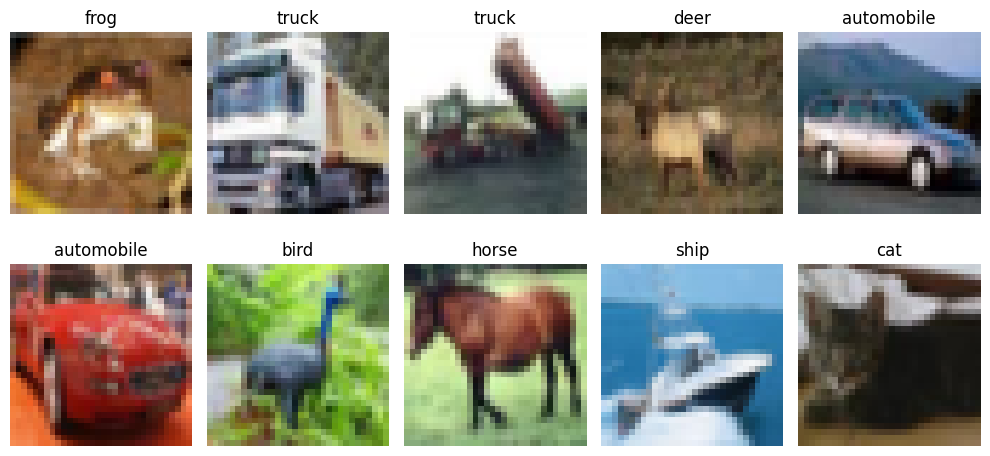

In [5]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [6]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [7]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.2690 - loss: 1.9979 - val_accuracy: 0.3370 - val_loss: 1.8592
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3095 - loss: 1.8788 - val_accuracy: 0.3478 - val_loss: 1.7988
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3219 - loss: 1.8418 - val_accuracy: 0.3430 - val_loss: 1.7877
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3386 - loss: 1.8041 - val_accuracy: 0.3816 - val_loss: 1.7364
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3538 - loss: 1.7761 - val_accuracy: 0.3982 - val_loss: 1.7016
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3576 - loss: 1.7582 - val_accuracy: 0.3990 - val_loss: 1.7134
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3657 - loss: 1.7429 - val_accuracy: 0.3962 - val_loss: 1.6954
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3740 - loss: 1.7260 - val_accuracy: 0.

In [8]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4224 - loss: 1.6666
ANN Test Accuracy: 0.42239999771118164


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [9]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.4676 - loss: 1.4929 - val_accuracy: 0.5620 - val_loss: 1.2245
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6088 - loss: 1.1206 - val_accuracy: 0.5600 - val_loss: 1.3883
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6709 - loss: 0.9513 - val_accuracy: 0.6248 - val_loss: 1.0865
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7127 - loss: 0.8284 - val_accuracy: 0.6650 - val_loss: 0.9797
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7452 - loss: 0.7340 - val_accuracy: 0.7008 - val_loss: 0.8880
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7689 - loss: 0.6564 - val_accuracy: 0.6826 - val_loss: 0.9211
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7915 - loss: 0.5921 - val_accuracy: 0.7076 - val_loss: 0.8649
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8149 - loss: 0.5312 - val_accuracy: 

In [10]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7051 - loss: 0.9827
CNN Test Accuracy: 0.7050999999046326


## 📈 Compare Learning Curves

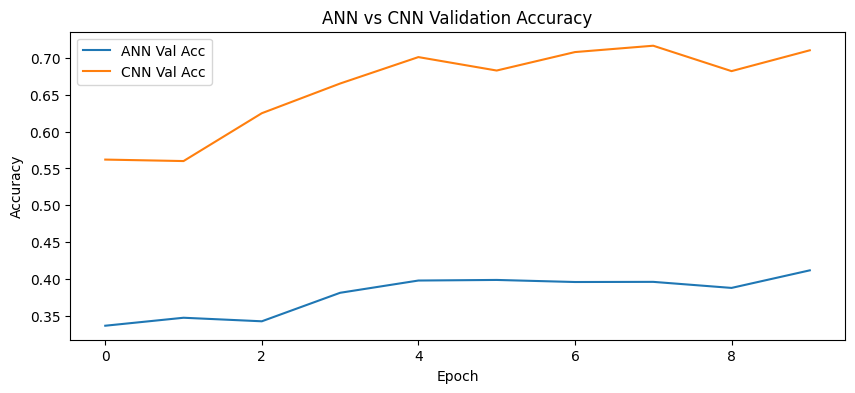

In [11]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

In [13]:
aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.3712 - loss: 1.7220 - val_accuracy: 0.5150 - val_loss: 1.3671
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.4730 - loss: 1.4673 - val_accuracy: 0.5664 - val_loss: 1.2002
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5122 - loss: 1.3636 - val_accuracy: 0.5640 - val_loss: 1.1958
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.5389 - loss: 1.3009 - val_accuracy: 0.5822 - val_loss: 1.1589
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5548 - loss: 1.2618 - val_accuracy: 0.6072 - val_loss: 1.1109
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5657 - loss: 1.2384 - val_accuracy: 0.5884 - val_loss: 1.1702
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5730 - loss: 1.2118 - val_accuracy: 0.6116 - val_loss: 1.0998
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5800 - loss: 1

In [14]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6363 - loss: 1.0364
Augmented CNN Test Accuracy: 0.6363000273704529


# 📊 Final Comparison Table

In [15]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4224
1,CNN,0.7051
2,CNN + Augmentation,0.6363


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# Task 1: Increase ANN Layers and Observe Performance

In [16]:
deep_ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Deeper')

deep_ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

deep_ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Deeper"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,837,066 (14.64 MB)

 Trainable params: 3,837,066 (14.64 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
deep_ann_history = deep_ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.2021 - loss: 2.1055 - val_accuracy: 0.2802 - val_loss: 1.9298
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2643 - loss: 1.9696 - val_accuracy: 0.3244 - val_loss: 1.9157
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2892 - loss: 1.9204 - val_accuracy: 0.3202 - val_loss: 1.9082
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3055 - loss: 1.8905 - val_accuracy: 0.3544 - val_loss: 1.8548
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3115 - loss: 1.8717 - val_accuracy: 0.3536 - val_loss: 1.8639
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3166 - loss: 1.8597 - val_accuracy: 0.3452 - val_loss: 1.8340
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3252 - loss: 1.8429 - val_accuracy: 0.3662 - val_loss: 1.8202
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3277 - loss: 1.8379 - val_accuracy: 

In [18]:
_, deep_ann_acc = deep_ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\nDeep ANN Test Accuracy: {deep_ann_acc:.4f}")
print(f"Original ANN Accuracy: {ann_test_acc:.4f}")
print(f"Improvement: {(deep_ann_acc - ann_test_acc)*100:.2f}%")


Deep ANN Test Accuracy: 0.3736
Original ANN Accuracy: 0.4224
Improvement: -4.88%


# Task 2: Change CNN Filters from 32 → 64 → 128

In [19]:
scaled_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Scaled_Filters_32_64_128')

scaled_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
scaled_cnn_history = scaled_cnn.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4424 - loss: 1.5734 - val_accuracy: 0.5982 - val_loss: 1.1492
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5938 - loss: 1.1498 - val_accuracy: 0.6134 - val_loss: 1.1580
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6627 - loss: 0.9594 - val_accuracy: 0.4916 - val_loss: 1.6086
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7132 - loss: 0.8214 - val_accuracy: 0.7074 - val_loss: 0.8391
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7528 - loss: 0.7102 - val_accuracy: 0.6410 - val_loss: 1.1143
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7851 - loss: 0.6136 - val_accuracy: 0.7180 - val_loss: 0.8704
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8130 - loss: 0.5330 - val_accuracy: 0.7520 - val_loss: 0.7861
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8381 - loss: 0.4610 - val_accuracy: 

In [21]:
_, scaled_cnn_acc = scaled_cnn.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nScaled CNN (32→64→128) Test Accuracy: {scaled_cnn_acc:.4f}")


Scaled CNN (32→64→128) Test Accuracy: 0.7290


# Task 3: Increase Epochs to 20

In [22]:
cnn_20ep = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_20_Epochs')

cnn_20ep.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [23]:
history_20ep = cnn_20ep.fit(x_train_norm, y_train, epochs=20, validation_split=0.1, batch_size=64, verbose=1)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.4209 - loss: 1.6120 - val_accuracy: 0.4106 - val_loss: 1.7791
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5756 - loss: 1.1857 - val_accuracy: 0.5856 - val_loss: 1.1673
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6580 - loss: 0.9727 - val_accuracy: 0.6872 - val_loss: 0.8984
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7111 - loss: 0.8241 - val_accuracy: 0.5108 - val_loss: 1.7838
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7513 - loss: 0.7158 - val_accuracy: 0.7306 - val_loss: 0.8010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7815 - loss: 0.6204 - val_accuracy: 0.6982 - val_loss: 1.0302
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8084 - loss: 0.5404 - val_accuracy: 0.7600 - val_loss: 0.7475
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8323 - loss: 0.4804 - val_accuracy: 

In [24]:
_, acc_20ep = cnn_20ep.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nCNN (20 epochs) Test Accuracy: {acc_20ep:.4f}")
print(f"CNN (10 epochs) Test Accuracy: {cnn_test_acc:.4f}")


CNN (20 epochs) Test Accuracy: 0.7355
CNN (10 epochs) Test Accuracy: 0.7051


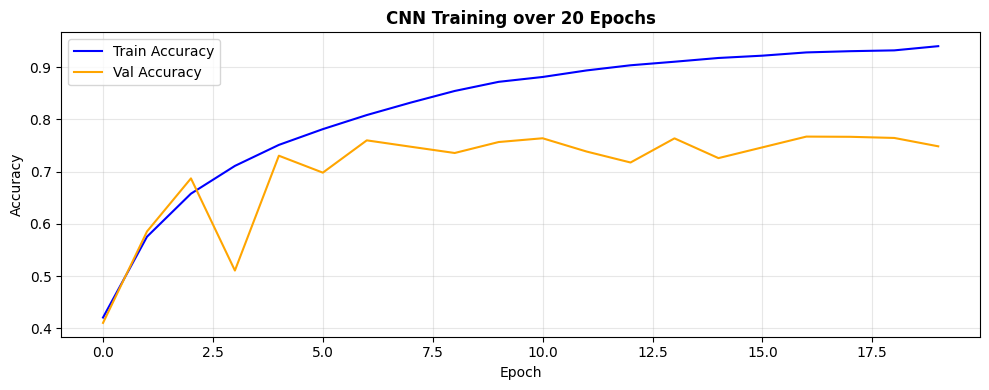

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(history_20ep.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_20ep.history['val_accuracy'], label='Val Accuracy',   color='orange')
plt.title('CNN Training over 20 Epochs', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Task 4: Add EarlyStopping

In [26]:
from tensorflow.keras import callbacks

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

cnn_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_EarlyStopping')

cnn_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
es_history = cnn_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 13ms/step - accuracy: 0.4484 - loss: 1.5604 - val_accuracy: 0.5786 - val_loss: 1.1541
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5974 - loss: 1.1471 - val_accuracy: 0.6336 - val_loss: 1.0744
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6721 - loss: 0.9463 - val_accuracy: 0.6224 - val_loss: 1.1448
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7175 - loss: 0.8119 - val_accuracy: 0.7050 - val_loss: 0.8491
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7506 - loss: 0.7124 - val_accuracy: 0.6972 - val_loss: 0.9028
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7786 - loss: 0.6327 - val_accuracy: 0.5114 - val_loss: 2.0228
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8025 - loss: 0.5585 - val_accuracy: 0.7244 - val_loss: 0.8406
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8292 - loss: 0.4801 - val_accuracy: 

In [28]:
actual_epochs = len(es_history.history['val_loss'])
_, es_acc = cnn_es.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nStopped at epoch: {actual_epochs}")
print(f"CNN with EarlyStopping Test Accuracy: {es_acc:.4f}")


Stopped at epoch: 12
CNN with EarlyStopping Test Accuracy: 0.7244


# Task 5: Add data augmentation training

In [29]:
data_aug_layer = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name='Augmentation_Pipeline')

full_aug_model = models.Sequential([
    data_aug_layer,
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_FullAugmented_Task5')

full_aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
full_aug_history = full_aug_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.3736 - loss: 1.7492 - val_accuracy: 0.4984 - val_loss: 1.4324
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4816 - loss: 1.4419 - val_accuracy: 0.5332 - val_loss: 1.3281
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5441 - loss: 1.2920 - val_accuracy: 0.6048 - val_loss: 1.1445
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5808 - loss: 1.1924 - val_accuracy: 0.6548 - val_loss: 1.0137
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6050 - loss: 1.1323 - val_accuracy: 0.5836 - val_loss: 1.2322
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


In [31]:
_, full_aug_acc = full_aug_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nFull Augmented CNN Test Accuracy: {full_aug_acc:.4f}")


Full Augmented CNN Test Accuracy: 0.4922


# Final Comparison Table

In [32]:
final_comparison = pd.DataFrame({
    "Model": [
        "ANN Baseline",
        "ANN Deeper",
        "CNN Baseline",
        "CNN Scaled Filters",
        "CNN 20 Epochs",
        "CNN EarlyStopping",
        "CNN + Augmentation"
    ],
    "Test Accuracy": [
        f"{ann_test_acc:.4f}",
        f"{deep_ann_acc:.4f}",
        f"{cnn_test_acc:.4f}",
        f"{scaled_cnn_acc:.4f}",
        f"{acc_20ep:.4f}",
        f"{es_acc:.4f}",
        f"{full_aug_acc:.4f}"
    ]
})

final_comparison

,Model,Test Accuracy
0,ANN Baseline,0.4224
1,ANN Deeper,0.3736
2,CNN Baseline,0.7051
3,CNN Scaled Filters,0.7290
4,CNN 20 Epochs,0.7355
5,CNN EarlyStopping,0.7244
6,CNN + Augmentation,0.4922


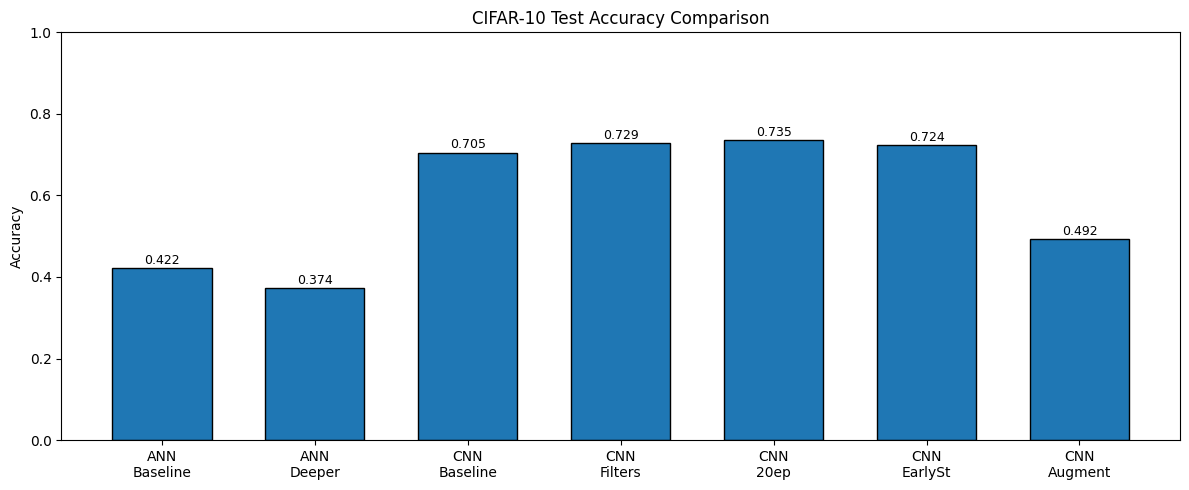

In [33]:
models_list = ['ANN\nBaseline','ANN\nDeeper','CNN\nBaseline', 'CNN\nFilters','CNN\n20ep','CNN\nEarlySt','CNN\nAugment']
accuracies = [ann_test_acc, deep_ann_acc, cnn_test_acc, scaled_cnn_acc, acc_20ep, es_acc, full_aug_acc]

plt.figure(figsize=(12,5))
bars = plt.bar(models_list, accuracies, edgecolor='black', width=0.65)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', fontsize=9)

plt.title('CIFAR-10 Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**